Bài toán dự đoán cổ phiếu sử dụng LTSF-Linear Models

Lấy dữ liệu ở trên cafef dưới dạng file excel

In [ ]:
import pandas as pd

# 1. Đọc file Excel (.xlsx)
# Chú ý: Đảm bảo tên file khớp hoàn toàn với tên file bạn đã upload lên Colab
file_path = "LichSuGia_VIC_01_01_2026_03_05_2026.xlsx"
df = pd.read_excel(file_path)

# 2. In ra tên các cột để kiểm tra định dạng thực tế trong file của bạn
print("Tên các cột hiện có trong file Excel:")
print(df.columns.tolist())

# 3. Xem thử 5 dòng đầu tiên
display(df.head())

Tên các cột hiện có trong file Excel:
['Ngay', 'GiaDieuChinh', 'GiaDongCua', 'ThayDoi', 'KhoiLuongKhopLenh', 'GiaTriKhopLenh', 'KLThoaThuan', 'GtThoaThuan', 'GiaMoCua', 'GiaCaoNhat', 'GiaThapNhat']


,Ngay,GiaDieuChinh,GiaDongCua,ThayDoi,KhoiLuongKhopLenh,GiaTriKhopLenh,KLThoaThuan,GtThoaThuan,GiaMoCua,GiaCaoNhat,GiaThapNhat
0,03/03/2026,"155,5","155,5","-11,7(-7,00 %)",6378300,1018032930000,0,0,164,167,"155,5"
1,02/03/2026,"167,2","167,2","-4,8(-2,79 %)",4989000,859334130000,0,0,171,"177,8",166
2,27/02/2026,172,172,"3,1(1,84 %)",3624400,628941610000,0,0,"169,1","178,5",168
3,26/02/2026,"168,9","168,9","10,9(6,90 %)",6775200,1130178600000,0,0,157,169,157
4,25/02/2026,158,158,"-4,9(-3,01 %)",5289800,833122860000,0,0,160,162,155


Sau đó chuyển về file csv cho đúng định dạng

In [ ]:
import pandas as pd

# 1. Đọc file excel (hoặc csv được lưu từ excel)
df = pd.read_excel('/content/LichSuGia_VIC_01_01_2026_03_05_2026.xlsx')


# 2. Xử lý định dạng số (Chuyển dấu ',' thành '.' và ép kiểu về float)
# Các cột cần xử lý: GiaMoCua, GiaCaoNhat, GiaThapNhat, GiaDongCua
cols_to_fix = ['GiaMoCua', 'GiaCaoNhat', 'GiaThapNhat', 'GiaDongCua']
for col in cols_to_fix:
    df[col] = df[col].astype(str).str.replace(',', '.').astype(float)

# 3. Chuyển đổi định dạng ngày tháng (từ DD/MM/YYYY sang YYYY-MM-DD)
df['Ngay'] = pd.to_datetime(df['Ngay'], format='%d/%m/%Y').dt.strftime('%Y-%m-%d')

# 4. Chọn và đổi tên các cột theo đúng định dạng ảnh mẫu
mapping = {
    'Ngay': 'time',
    'GiaMoCua': 'open',
    'GiaCaoNhat': 'high',
    'GiaThapNhat': 'low',
    'GiaDongCua': 'close',
    'KhoiLuongKhopLenh': 'volume'
}

# Lọc các cột cần thiết
df_final = df[list(mapping.keys())].rename(columns=mapping)

# 5. Thêm cột 'symbol' (Giá trị là VIC theo tên file của bạn)
df_final['symbol'] = 'VIC'

# 6. Sắp xếp lại theo thời gian tăng dần (như trong ảnh mẫu)
df_final = df_final.sort_values(by='time').reset_index(drop=True)

# 7. Lưu ra file CSV mới
df_final.to_csv('VIC_transformed.csv', index=False)

print("Đã chuyển đổi xong! Dưới đây là 5 dòng đầu tiên:")
print(df_final.head())

Đã chuyển đổi xong! Dưới đây là 5 dòng đầu tiên:
         time   open   high    low  close   volume symbol
0  2026-01-05  169.6  174.5  166.8  173.1  6644800    VIC
1  2026-01-06  173.6  176.0  171.4  173.1  7681000    VIC
2  2026-01-07  173.1  179.5  168.6  179.0  7674800    VIC
3  2026-01-08  183.5  190.0  176.6  176.6  6593700    VIC
4  2026-01-09  176.0  180.2  172.6  176.0  5389600    VIC


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import matplotlib.dates as mdates

import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8")
sns.set_palette("husl")
print(f"Device available: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

# Đọc dữ liệu
df = pd.read_csv("/content/VIC_transformed.csv")
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['time'].min()} to {df['time'].max()}")

# Xử lý và sắp xếp theo thời gian
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time").reset_index(drop=True)

# Thông tin cơ bản
print("\nFirst few rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nBasic statistics:")
display(df.describe())

Device available: CPU
Dataset shape: (37, 7)
Date range: 2026-01-05 to 2026-03-03

First few rows:


,time,open,high,low,close,volume,symbol
0,2026-01-05,169.6,174.5,166.8,173.1,6644800,VIC
1,2026-01-06,173.6,176.0,171.4,173.1,7681000,VIC
2,2026-01-07,173.1,179.5,168.6,179.0,7674800,VIC
3,2026-01-08,183.5,190.0,176.6,176.6,6593700,VIC
4,2026-01-09,176.0,180.2,172.6,176.0,5389600,VIC



Data types:
time      datetime64[ns]
open             float64
high             float64
low              float64
close            float64
volume             int64
symbol            object
dtype: object

Basic statistics:


,time,open,high,low,close,volume
count,37,37.000000,37.000000,37.000000,37.000000,3.700000e+01
mean,2026-01-30 18:09:43.783783680,156.045946,160.416216,151.735135,155.659459,5.888216e+06
min,2026-01-05 00:00:00,119.000000,129.800000,118.900000,121.600000,1.947400e+06
25%,2026-01-16 00:00:00,148.000000,151.300000,140.500000,141.500000,3.824600e+06
50%,2026-01-29 00:00:00,160.000000,163.600000,155.500000,160.000000,5.436200e+06
75%,2026-02-11 00:00:00,167.000000,171.200000,159.600000,165.400000,7.311200e+06
max,2026-03-03 00:00:00,183.500000,190.000000,176.600000,179.000000,1.170400e+07
std,NaN,15.938573,15.800132,15.162513,15.235147,2.391334e+06


Bước 2: Khám phá dữ liệu

Trong bước này, hai đặc trưng cơ bản được tạo ra từ giá trị close:
+ Daily_retrun: Phần trăm thay đổi giá giữa 2 ngày liên tiếp, phản ánh biến động ngắn hạn
+ Close_log: log tự nhiên của giá đóng cửa, giảm độ lệch và ổn định phân phối dự liệu

In [ ]:
# Tạo essential features
print("1. Tạo essential features:")
df["daily_return"] = df["close"].pct_change()
df["close_log"] = np.log(df["close"])
print(" - daily_return: phần trăm thay đổi hàng ngày")
print(" - close_log: log giá đóng cửa")

# Kiểm tra missing values cho TẤT CẢ các cột
missing_info = df.isnull().sum()

# Chỉ xử lý giá trị khuyết cần thiết
if df["daily_return"].isnull().sum() > 0:
    df["daily_return"].fillna(0, inplace=True)

# Kiểm tra lại sau khi xử lý
missing_after = df.isnull().sum()
missing_after


1. Tạo essential features:
 - daily_return: phần trăm thay đổi hàng ngày
 - close_log: log giá đóng cửa


,0
time,0
open,0
high,0
low,0
close,0
volume,0
symbol,0
daily_return,0
close_log,0


VIC Stock Data analysis

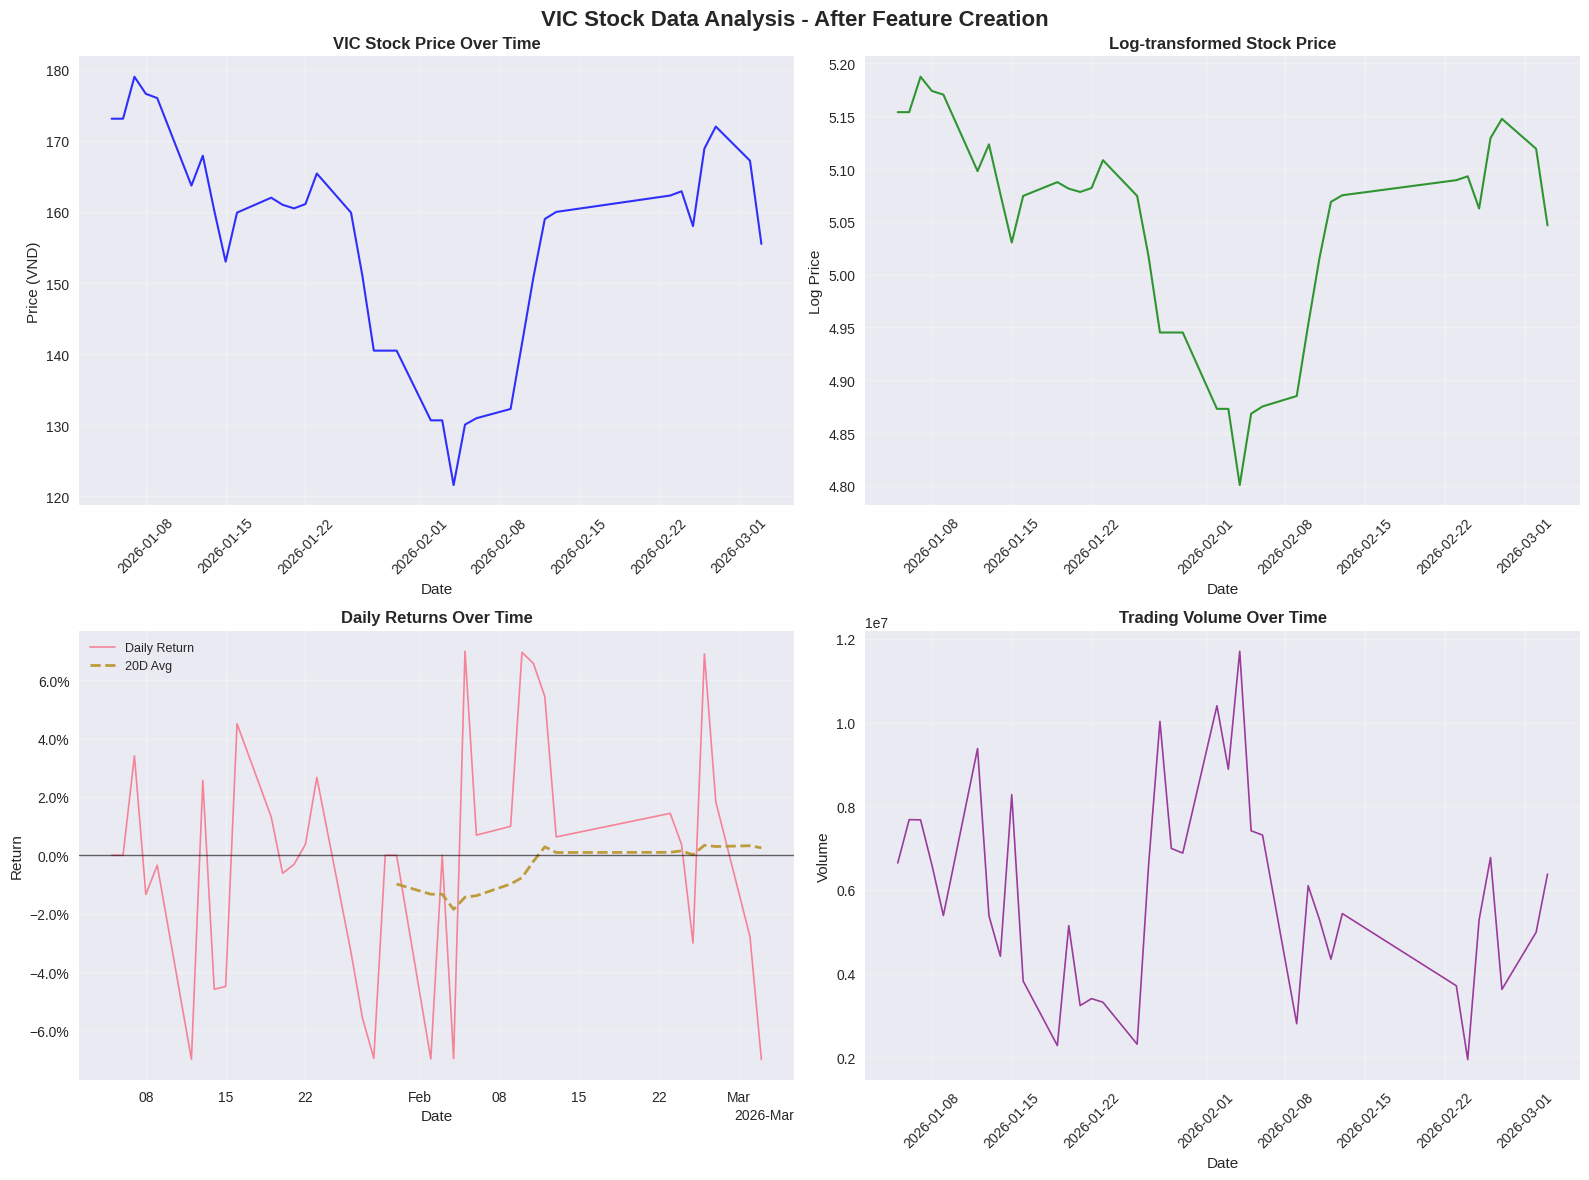

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter

# Khởi tạo figure và axes
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("VIC Stock Data Analysis - After Feature Creation", fontsize=16, fontweight="bold")

# 1) Stock Price Over Time
axes[0, 0].plot(df["time"], df["close"], linewidth=1.5, color="blue", alpha=0.8)
axes[0, 0].set_title("VIC Stock Price Over Time", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Price (VND)")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis="x", rotation=45)

# 2) Log-transformed Price
axes[0, 1].plot(df["time"], df["close_log"], linewidth=1.5, color="green", alpha=0.8)
axes[0, 1].set_title("Log-transformed Stock Price", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Date")
axes[0, 1].set_ylabel("Log Price")
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].tick_params(axis="x", rotation=45)

# 3) Daily Returns Over Time
ret_ts = df[["time", "daily_return"]].dropna().copy()
ret_ts["ret_ma20"] = ret_ts["daily_return"].rolling(20).mean()

axes[1, 0].plot(ret_ts["time"], ret_ts["daily_return"], linewidth=1.2, alpha=0.85, label="Daily Return")
axes[1, 0].plot(ret_ts["time"], ret_ts["ret_ma20"], linewidth=2.0, linestyle="--", alpha=0.95, label="20D Avg")
axes[1, 0].axhline(0, color="black", linewidth=1, alpha=0.6)
axes[1, 0].set_title("Daily Returns Over Time", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Date")
axes[1, 0].set_ylabel("Return")
axes[1, 0].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1, 0].xaxis.set_major_locator(mdates.AutoDateLocator())
axes[1, 0].xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
axes[1, 0].tick_params(axis="x", rotation=0)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(fontsize=9)

# 4) Volume Over Time
axes[1, 1].plot(df["time"], df["volume"], linewidth=1.2, color="purple", alpha=0.75)
axes[1, 1].set_title("Trading Volume Over Time", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Date")
axes[1, 1].set_ylabel("Volume")
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset

class UnivariateTimeSeriesDataset(Dataset):
    """Dataset cho dự báo chuỗi thời gian đơn biến - dự đoán 5 ngày tới"""
    def __init__(self, data, seq_len, pred_len=5, target_col="close", normalize=False):
        self.data = data.dropna().reset_index(drop=True)
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.target_col = target_col
        self.normalize = normalize

        self.series = self.data[target_col].values

        if normalize:
            self.mean = np.mean(self.series)
            self.std = np.std(self.series)

    def __len__(self):
        # Tổng số mẫu có thể tạo ra từ chuỗi thời gian
        return len(self.series) - self.seq_len - self.pred_len + 1

    def __getitem__(self, idx):
        # Lấy đoạn dữ liệu quá khứ (đầu vào x)
        x = self.series[idx : idx + self.seq_len].copy()
        # Lấy đoạn dữ liệu tương lai (nhãn y)
        y = self.series[idx + self.seq_len : idx + self.seq_len + self.pred_len].copy()

        if self.normalize:
            x = (x - self.mean) / self.std
            y = (y - self.mean) / self.std

        return torch.FloatTensor(x), torch.FloatTensor(y)

    def denormalize(self, normalized_values):
        if not self.normalize:
            return normalized_values
        return normalized_values * self.std + self.mean

def create_univariate_datasets(df, seq_lengths, pred_len=5, target_col="close"):
    """Tạo các dataset đơn biến cho các độ dài chuỗi đầu vào khác nhau"""
    datasets = {}

    for seq_len in seq_lengths:
        dataset = UnivariateTimeSeriesDataset(
            data=df, seq_len=seq_len, pred_len=pred_len,
            target_col=target_col, normalize=False
        )
        datasets[f"{seq_len}d"] = dataset

    return datasets

# Khởi tạo dataset cho dự báo 5 ngày với các độ dài đầu vào khác nhau
seq_lengths = [5, 10, 15, 20]
pred_len = 5 # Dự đoán 5 ngày kế tiếp

# Tạo các dataset sử dụng giá log (log prices) để tăng tính ổn định
datasets = create_univariate_datasets(df, seq_lengths, pred_len, "close_log")

print(f"Created datasets for 5-day prediction with input lengths: {seq_lengths}")
for name, dataset in datasets.items():
    print(f"- {name}: {len(dataset)} samples")

print("Using log-transformed prices for stability.")

Created datasets for 5-day prediction with input lengths: [5, 10, 15, 20]
- 5d: 28 samples
- 10d: 23 samples
- 15d: 18 samples
- 20d: 13 samples
Using log-transformed prices for stability.


Tạo tập dữ liệu 70% cho huấn luyện, 15% cho valid và 15% cho Test và không shuffling

In [ ]:
import torch

def create_time_based_splits(dataset, train_ratio=0.7, val_ratio=0.15):
    """Tạo các phần chia dữ liệu dựa trên thời gian cho chuỗi thời gian"""
    total_len = len(dataset)
    train_len = int(total_len * train_ratio)
    val_len = int(total_len * val_ratio)

    # Chia chỉ số dựa trên thời gian (không tráo đổi để giữ thứ tự thời gian)
    train_indices = list(range(0, train_len))
    val_indices = list(range(train_len, train_len + val_len))
    test_indices = list(range(train_len + val_len, total_len))

    # Sử dụng Subset để tạo các tập dữ liệu con từ chỉ số đã chia
    train_dataset = torch.utils.data.Subset(dataset, train_indices)
    val_dataset = torch.utils.data.Subset(dataset, val_indices)
    test_dataset = torch.utils.data.Subset(dataset, test_indices)

    return train_dataset, val_dataset, test_dataset

# Tạo các tập chia cho tất cả các độ dài chuỗi (seq_lengths)
data_splits = {}

print("Creating time-based data splits:")
print("- Train: 70%, Validation: 15%, Test: 15%")
print("- Temporal order preserved (no shuffling)")

for seq_name, dataset in datasets.items():
    train, val, test = create_time_based_splits(dataset)
    data_splits[seq_name] = {
        "train": train,
        "val": val,
        "test": test
    }

print(f"\nTotal datasets with splits: {len(data_splits)}")

# Kiểm tra tính toàn vẹn của dữ liệu sau khi chia
print(f"\n=== SPLIT VERIFICATION ===")
for seq_name, splits in data_splits.items():
    total_samples = len(splits["train"]) + len(splits["val"]) + len(splits["test"])
    original_samples = len(datasets[seq_name])

    if total_samples == original_samples:
        print(f"{seq_name}: {total_samples}/{original_samples} samples")
    else:
        print(f"{seq_name}: ERROR - {total_samples}/{original_samples}")

print("\nData splits created successfully!")

Creating time-based data splits:
- Train: 70%, Validation: 15%, Test: 15%
- Temporal order preserved (no shuffling)

Total datasets with splits: 4

=== SPLIT VERIFICATION ===
5d: 28/28 samples
10d: 23/23 samples
15d: 18/18 samples
20d: 13/13 samples

Data splits created successfully!


Xây dựng và khởi tạo model

In [ ]:
import torch
import torch.nn as nn

# 1. Mô hình Linear đơn giản
class Linear(nn.Module):
    """Mô hình Linear cơ bản cho dự báo chuỗi thời gian đơn biến"""
    def __init__(self, seq_len, pred_len=5):
        super(Linear, self).__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.linear = nn.Linear(self.seq_len, self.pred_len)

    def forward(self, x):
        # x: [batch_size, seq_len]
        # x.unsqueeze(1) nếu dữ liệu có dạng [batch, seq_len, 1]
        return self.linear(x)

# 2. Mô hình DLinear (Decomposition Linear)
class DLinear(nn.Module):
    """Mô hình phân rã chuỗi thời gian thành Xu hướng (Trend) và Mùa vụ (Seasonal)"""
    def __init__(self, seq_len, pred_len=5, moving_avg=5):
        super(DLinear, self).__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.moving_avg = min(moving_avg, seq_len - 1)

        # Hai lớp tuyến tính riêng biệt cho hai thành phần
        self.linear_trend = nn.Linear(self.seq_len, self.pred_len)
        self.linear_seasonal = nn.Linear(self.seq_len, self.pred_len)

        # Tạo kernel trung bình trượt để trích xuất xu hướng
        self.register_buffer('avg_kernel', torch.ones(1, 1, self.moving_avg) / self.moving_avg)

    def decompose(self, x):
        """Phân rã chuỗi thành Trend và Seasonal"""
        batch_size, seq_len = x.shape
        x_reshaped = x.unsqueeze(1) # [batch, 1, seq_len]

        # Áp dụng trung bình trượt để lấy Trend
        padding = self.moving_avg // 2
        x_padded = torch.nn.functional.pad(x_reshaped, (padding, padding), mode='replicate')
        trend = torch.nn.functional.conv1d(x_padded, self.avg_kernel, padding=0)
        trend = trend.squeeze(1)

        # Xử lý kích thước nếu bị lệch do padding
        if trend.shape[1] != seq_len:
            trend = torch.nn.functional.interpolate(
                trend.unsqueeze(1), size=seq_len, mode='linear', align_corners=False
            ).squeeze(1)

        # Seasonal = Bản gốc - Trend
        seasonal = x - trend
        return seasonal, trend

    def forward(self, x):
        seasonal, trend = self.decompose(x)

        # Dự báo riêng biệt từng thành phần
        seasonal_pred = self.linear_seasonal(seasonal)
        trend_pred = self.linear_trend(trend)

        # Kết quả cuối cùng là tổng của hai thành phần dự báo
        return seasonal_pred + trend_pred

# 3. Mô hình NLinear (Normalized Linear)
class NLinear(nn.Module):
    """Mô hình Linear có chuẩn hóa để xử lý sự thay đổi phân phối (distribution shift)"""
    def __init__(self, seq_len, pred_len=5):
        super(NLinear, self).__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.linear = nn.Linear(self.seq_len, self.pred_len)

    def forward(self, x):
        # 1. Lấy giá trị cuối cùng của chuỗi đầu vào
        last_value = x[:, -1:].detach()

        # 2. Trừ đi giá trị cuối cùng (Normalize)
        x_normalized = x - last_value

        # 3. Dự báo trên dữ liệu đã chuẩn hóa
        pred_normalized = self.linear(x_normalized)

        # 4. Cộng lại giá trị cuối cùng (Denormalize)
        pred = pred_normalized + last_value
        return pred

print("LTSF-Linear models implemented for 5-day univariate forecasting.")

LTSF-Linear models implemented for 5-day univariate forecasting.


Tạo cấu hình và khởi tạo mô hình

In [ ]:
# Cấu hình các khoảng thời gian đầu vào (Horizon) để dự báo 5 ngày tới
horizon_configs = {
    '5d': {'seq_len': 5, 'pred_len': 5},
    '10d': {'seq_len': 30, 'pred_len': 5},
    '15d': {'seq_len': 120, 'pred_len': 5},
    '20d': {'seq_len': 480, 'pred_len': 5}
}

# Khởi tạo các instance của mô hình cho từng tổ hợp cấu hình
model_configs = {
    'Linear': {},
    'DLinear': {},
    'NLinear': {}
}

print("Creating model instances for 5-day prediction:")
for horizon, config in horizon_configs.items():
    seq_len = config['seq_len']
    pred_len = config['pred_len']

    # Khởi tạo và lưu trữ các biến thể của mô hình Linear
    model_configs['Linear'][horizon] = {
        'model': Linear(seq_len, pred_len),
        'seq_len': seq_len,
        'pred_len': pred_len
    }

    # Khởi tạo và lưu trữ các biến thể của mô hình DLinear
    model_configs['DLinear'][horizon] = {
        'model': DLinear(seq_len, pred_len),
        'seq_len': seq_len,
        'pred_len': pred_len
    }

    # Khởi tạo và lưu trữ các biến thể của mô hình NLinear
    model_configs['NLinear'][horizon] = {
        'model': NLinear(seq_len, pred_len),
        'seq_len': seq_len,
        'pred_len': pred_len
    }

    print(f"  {horizon}: seq_len={seq_len}, pred_len={pred_len}")

Creating model instances for 5-day prediction:
  5d: seq_len=5, pred_len=5
  10d: seq_len=30, pred_len=5
  15d: seq_len=120, pred_len=5
  20d: seq_len=480, pred_len=5


Huấn luyện và trực quan hóa Loss

Normalize dataset

In [ ]:
import torch
import numpy as np
from torch.utils.data import Dataset, Subset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Cấu hình thiết bị (Ưu tiên GPU nếu có)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class NormalizedDataset(Dataset):
    """Lớp Dataset hỗ trợ chuẩn hóa dữ liệu đầu vào và đầu ra"""
    def __init__(self, original_dataset, scaler=None):
        self.original_dataset = original_dataset

        # Nếu chưa có scaler, tiến hành tính toán (fit) trên toàn bộ dữ liệu của dataset này
        if scaler is None:
            all_data = []
            for i in range(len(original_dataset)):
                x, y = original_dataset[i]
                all_data.extend(x.numpy())
                all_data.extend(y.numpy())

            self.scaler = StandardScaler()
            self.scaler.fit(np.array(all_data).reshape(-1, 1))
        else:
            self.scaler = scaler

    def __len__(self):
        return len(self.original_dataset)

    def __getitem__(self, idx):
        x, y = self.original_dataset[idx]

        # Chuẩn hóa x và y về phân phối chuẩn (mean=0, std=1)
        x_norm = self.scaler.transform(x.numpy().reshape(-1, 1)).flatten()
        y_norm = self.scaler.transform(y.numpy().reshape(-1, 1)).flatten()

        return torch.FloatTensor(x_norm), torch.FloatTensor(y_norm)

    def denormalize(self, normalized_values):
        """Chuyển đổi giá trị đã chuẩn hóa về lại đơn vị gốc (ví dụ: VND)"""
        return self.scaler.inverse_transform(normalized_values.reshape(-1, 1)).flatten()

# 1. Tạo các dataset đã được chuẩn hóa
normalized_datasets = {}
scaler = None

for horizon, dataset in datasets.items():
    normalized_dataset = NormalizedDataset(dataset, scaler)
    if scaler is None:
        # Lưu lại scaler đầu tiên để dùng chung cho tất cả các tập (5d, 30d,...)
        scaler = normalized_dataset.scaler
    normalized_datasets[horizon] = normalized_dataset

# 2. Chia dữ liệu (Train/Val/Test) trên tập đã chuẩn hóa
normalized_data_splits = {}
for horizon in datasets.keys():
    total_len = len(normalized_datasets[horizon])
    train_len = int(total_len * 0.7)
    val_len = int(total_len * 0.15)

    train_indices = list(range(0, train_len))
    val_indices = list(range(train_len, train_len + val_len))
    test_indices = list(range(train_len + val_len, total_len))

    normalized_data_splits[horizon] = {
        'train': Subset(normalized_datasets[horizon], train_indices),
        'val': Subset(normalized_datasets[horizon], val_indices),
        'test': Subset(normalized_datasets[horizon], test_indices)
    }

# 3. Hàm đánh giá mô hình với dữ liệu chuẩn hóa
def evaluate_model_normalized(model, test_loader, scaler, device='cpu'):
    """Đánh giá mô hình và trả về kết quả ở đơn vị gốc"""
    model.eval()
    predictions = []
    actuals = []

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)

            # Đưa dự báo và thực tế về đơn vị gốc trước khi tính toán lỗi
            for i in range(outputs.shape[0]):
                pred_denorm = scaler.inverse_transform(outputs[i].cpu().numpy().reshape(-1, 1)).flatten()
                actual_denorm = scaler.inverse_transform(batch_y[i].cpu().numpy().reshape(-1, 1)).flatten()
                predictions.extend(pred_denorm)
                actuals.extend(actual_denorm)

    predictions = np.array(predictions)
    actuals = np.array(actuals)

    # Tính toán các chỉ số lỗi trên thang đo gốc
    mse = mean_squared_error(actuals, predictions)
    mae = mean_absolute_error(actuals, predictions)
    rmse = np.sqrt(mse)

    try:
        r2 = r2_score(actuals, predictions)
    except:
        r2 = -999

    return {
        'mse': mse,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'predictions': predictions,
        'actuals': actuals
    }

Train và visualize

In [ ]:
import torch
import torch.nn as nn

def train_model(model, train_loader, val_loader, num_epochs=50, lr=0.001, device="cpu"):
    """Huấn luyện một mô hình và trả về lịch sử MSE của tập train/val qua từng epoch."""
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # Giảm tốc độ học (Learning Rate) sau mỗi 20 epoch để hội tụ tốt hơn
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

    model.to(device)
    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        # --- GIAI ĐOẠN HUẤN LUYỆN (TRAIN) ---
        model.train()
        epoch_train_loss = 0.0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            # Xóa gradient cũ
            optimizer.zero_grad()
            # Dự báo (Forward pass)
            preds = model(batch_x)
            # Tính toán lỗi
            loss = criterion(preds, batch_y)
            # Lan truyền ngược (Backward pass)
            loss.backward()
            # Cập nhật trọng số
            optimizer.step()

            epoch_train_loss += loss.item()

        # Tính loss trung bình cho tập train
        train_losses.append(epoch_train_loss / max(1, len(train_loader)))

        # --- GIAI ĐOẠN KIỂM ĐỊNH (VALIDATION) ---
        model.eval()
        epoch_val_loss = 0.0
        with torch.no_grad(): # Không tính toán gradient để tiết kiệm bộ nhớ
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                preds = model(batch_x)
                epoch_val_loss += criterion(preds, batch_y).item()

        # Tính loss trung bình cho tập validation
        val_losses.append(epoch_val_loss / max(1, len(val_loader)))

        # Cập nhật Learning Rate dựa trên scheduler
        scheduler.step()

    return model, train_losses, val_losses

Bắt đầu huấn luyện với các cấu hình: ['5d', '10d', '15d', '20d']
Tiến hành khởi tạo lại mô hình cho khớp với dữ liệu hiện tại...
 - Đã tạo mô hình cho 5d (Đầu vào: 5, Đầu ra: 5)
 - Đã tạo mô hình cho 10d (Đầu vào: 10, Đầu ra: 5)
 - Đã tạo mô hình cho 15d (Đầu vào: 15, Đầu ra: 5)
 - Đã tạo mô hình cho 20d (Đầu vào: 20, Đầu ra: 5)
--------------------------------------------------

--- Đang chạy cho 5d ---

--- Đang chạy cho 10d ---

--- Đang chạy cho 15d ---

--- Đang chạy cho 20d ---


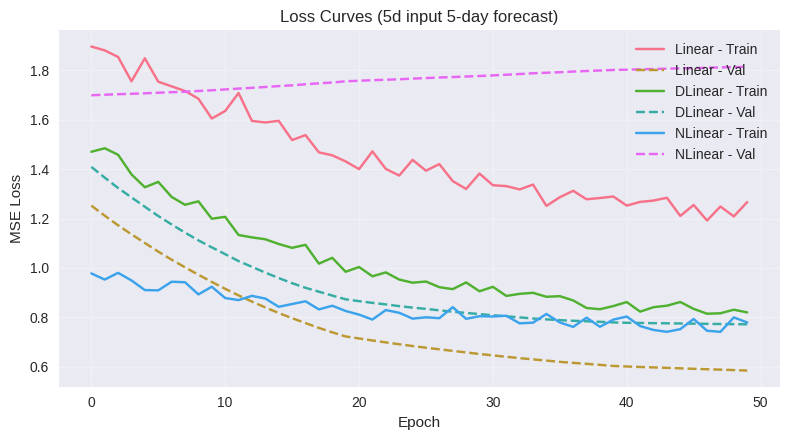

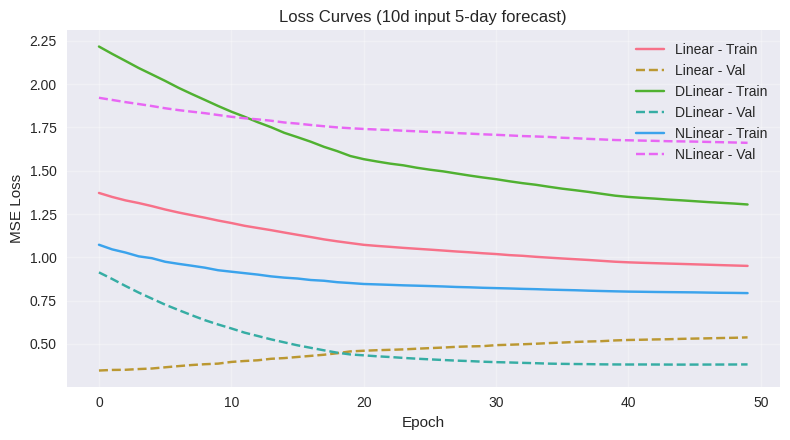

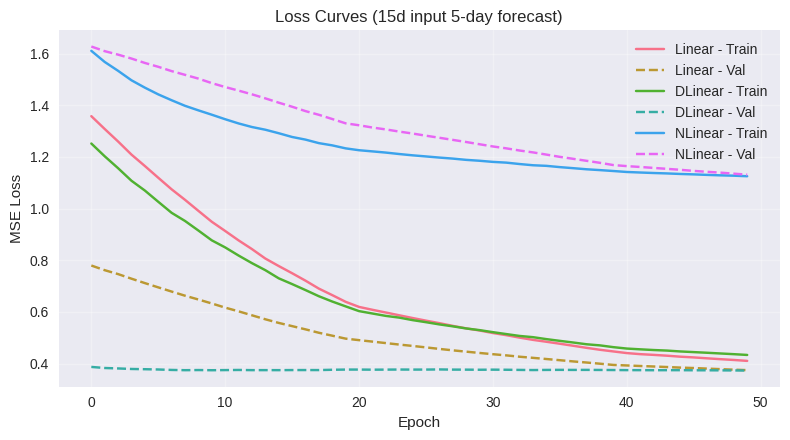

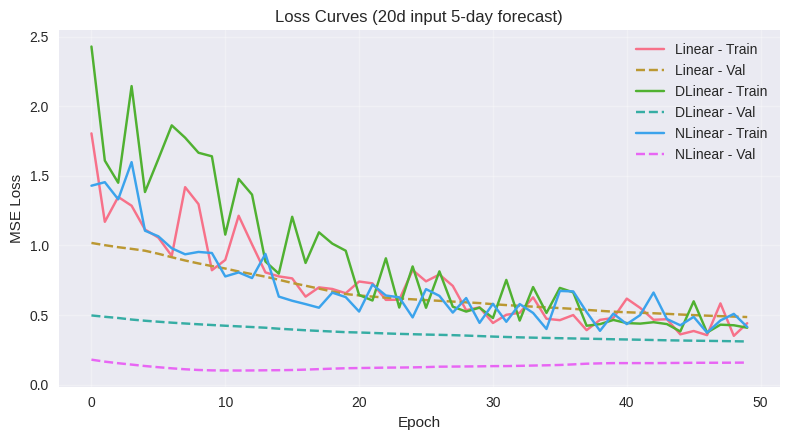

In [ ]:
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

batch_size = 4
num_epochs = 50
learning_rate = 0.001

# --- PHẦN ĐÃ SỬA: Tự động lấy các horizon đang có sẵn thay vì gõ tay ---
active_horizons = list(normalized_data_splits.keys())
print(f"Bắt đầu huấn luyện với các cấu hình: {active_horizons}")

results = {"Linear": {}, "DLinear": {}, "NLinear": {}}
trained_models = {"Linear": {}, "DLinear": {}, "NLinear": {}}
loss_history = {"Linear": {}, "DLinear": {}, "NLinear": {}}

print("Tiến hành khởi tạo lại mô hình cho khớp với dữ liệu hiện tại...")
model_configs = {"Linear": {}, "DLinear": {}, "NLinear": {}}
pred_len = 5 # Dự báo 5 ngày

for horizon in active_horizons:
    # Trích xuất con số từ chuỗi (ví dụ: '10d' -> 10)
    seq_len = int(horizon.replace('d', ''))

    # Khởi tạo mô hình mới với đúng seq_len hiện tại
    model_configs['Linear'][horizon] = {
        'model': Linear(seq_len, pred_len), 'seq_len': seq_len, 'pred_len': pred_len
    }
    model_configs['DLinear'][horizon] = {
        'model': DLinear(seq_len, pred_len), 'seq_len': seq_len, 'pred_len': pred_len
    }
    model_configs['NLinear'][horizon] = {
        'model': NLinear(seq_len, pred_len), 'seq_len': seq_len, 'pred_len': pred_len
    }
    print(f" - Đã tạo mô hình cho {horizon} (Đầu vào: {seq_len}, Đầu ra: {pred_len})")
print("-" * 50)
# -----

for horizon in active_horizons:
    print(f"\n--- Đang chạy cho {horizon} ---")
    train_loader = DataLoader(
        normalized_data_splits[horizon]["train"],
        batch_size=batch_size, shuffle=True, drop_last=False
    )
    val_loader = DataLoader(
        normalized_data_splits[horizon]["val"],
        batch_size=batch_size, shuffle=False, drop_last=False
    )
    test_loader = DataLoader(
        normalized_data_splits[horizon]["test"],
        batch_size=batch_size, shuffle=False, drop_last=False
    )

    for model_name in ["Linear", "DLinear", "NLinear"]:
        # Kiểm tra xem mô hình cho horizon này đã được khởi tạo chưa
        if horizon not in model_configs[model_name]:
            print(f"Bỏ qua {model_name} - {horizon} do chưa được khởi tạo.")
            continue

        model = model_configs[model_name][horizon]["model"]

        trained_model, tr_losses, va_losses = train_model(
            model, train_loader, val_loader,
            num_epochs=num_epochs, lr=learning_rate, device=device
        )

        loss_history[model_name][horizon] = {"train": tr_losses, "val": va_losses}
        trained_models[model_name][horizon] = trained_model

        test_results = evaluate_model_normalized(
            trained_model, test_loader, scaler, device
        )
        results[model_name][horizon] = test_results

# Trực quan hóa kết quả
if active_horizons:
    plot_loss_curves(loss_history, horizons=active_horizons)